# Gradient scan vs training AD scores

This notebook follows the same conventions as:

- `collect_attns_modal.py` for loading training attentions from H5 shards.
- `conditioned_VAE_trainer.ipynb` for the FiLM-conditioned VAE definition.
- `gradient_scan_modal.py` for padding, masking, and AD-score computation.

It:

- Loads the trained FiLM-conditioned VAE.
- Recomputes AD scores on a sample of the training attention matrices.
- Loads `gradient_scan_results.jsonl` from the Modal scan.
- Produces comparison plots for AD scores and gradient norms.


In [1]:
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------
# Paths -- adjust as needed
# ------------------------------------------------------------------

# JSONL produced by gradient_scan_modal.py (downloaded from Modal volume)
GRAD_SCAN_PATH = Path("../gradient_scan_results.jsonl")

# VAE checkpoint (download from Modal vae-checkpoints volume if needed)
# e.g. `modal volume get vae-checkpoints vae_latest.pt` in this directory
VAE_CHECKPOINT_PATH = Path("../trained_models/dormant2_vae_checkpoints/vae_latest.pt")

# Directory containing training attention H5 shards, downloaded from
# the `attention-output` volume (see collect_attns_modal.py)
# Example command:
#   modal volume get attention-output attention_data ./attention_data_modal
TRAIN_ATTNS_DIR = Path("../attention_data")

# Model / VAE hyperparameters (must match training + gradient_scan_modal.py)
NUM_LAYERS = 61
MAX_SEQ_LEN = 128
VAE_LATENT_CHANNELS = 2
VAE_LATENT_SPATIAL = 2
VAE_COND_DIM = 64
AD_METRIC = "k_sum"  # "sum", "max", or "k_sum"
TOP_K = 5
MAX_TRAIN_PROMPTS = 2000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Grad scan path: {GRAD_SCAN_PATH}")
print(f"VAE checkpoint path: {VAE_CHECKPOINT_PATH}")
print(f"Training attns dir: {TRAIN_ATTNS_DIR}")

Using device: cuda
Grad scan path: ../gradient_scan_results.jsonl
VAE checkpoint path: ../trained_models/dormant2_vae_checkpoints/vae_latest.pt
Training attns dir: ../attention_data


In [2]:
# ------------------------------------------------------------------
# FiLM-conditioned VAE definition (must match training notebook)
# ------------------------------------------------------------------

class FiLMLayer(nn.Module):
    """Feature-wise Linear Modulation for conv feature maps."""

    def __init__(self, cond_dim, num_channels):
        super().__init__()
        self.fc = nn.Linear(cond_dim, num_channels * 2)

    def forward(self, x, cond):
        params = self.fc(cond)
        gamma, beta = params.chunk(2, dim=-1)
        gamma = gamma.unsqueeze(-1).unsqueeze(-1)
        beta = beta.unsqueeze(-1).unsqueeze(-1)
        return gamma * x + beta


class FiLMConditionedVAE(nn.Module):
    """Conv VAE with FiLM conditioning on a discrete layer index."""

    def __init__(self, num_layers=61, input_size=128,
                 latent_channels=2, latent_spatial=2, cond_dim=64):
        super().__init__()
        self.input_size = input_size
        self.latent_channels = latent_channels
        self.latent_spatial = latent_spatial
        self.layer_embed = nn.Embedding(num_layers, cond_dim)

        self.enc_conv1 = nn.Conv2d(1, 4, kernel_size=4, stride=2, padding=1)
        self.enc_bn1 = nn.BatchNorm2d(4, affine=False)
        self.enc_film1 = FiLMLayer(cond_dim, 4)
        self.enc_conv2 = nn.Conv2d(4, 8, kernel_size=4, stride=2, padding=1)
        self.enc_bn2 = nn.BatchNorm2d(8, affine=False)
        self.enc_film2 = FiLMLayer(cond_dim, 8)
        self.enc_conv3 = nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=1)
        self.enc_bn3 = nn.BatchNorm2d(16, affine=False)
        self.enc_film3 = FiLMLayer(cond_dim, 16)
        self.enc_pool = nn.AdaptiveAvgPool2d(latent_spatial)

        flat_dim = 16 * latent_spatial * latent_spatial
        latent_dim = latent_channels * latent_spatial * latent_spatial
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 16 * latent_spatial * latent_spatial)
        self._pre_pool_size = input_size // 8

        self.dec_up = nn.Upsample(size=self._pre_pool_size)
        self.dec_conv1 = nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1)
        self.dec_bn1 = nn.BatchNorm2d(8, affine=False)
        self.dec_film1 = FiLMLayer(cond_dim, 8)
        self.dec_conv2 = nn.ConvTranspose2d(8, 4, kernel_size=4, stride=2, padding=1)
        self.dec_bn2 = nn.BatchNorm2d(4, affine=False)
        self.dec_film2 = FiLMLayer(cond_dim, 4)
        self.dec_conv3 = nn.ConvTranspose2d(4, 1, kernel_size=4, stride=2, padding=1)

    def _encode(self, x, cond):
        h = F.relu(self.enc_film1(self.enc_bn1(self.enc_conv1(x)), cond))
        h = F.relu(self.enc_film2(self.enc_bn2(self.enc_conv2(h)), cond))
        h = F.relu(self.enc_film3(self.enc_bn3(self.enc_conv3(h)), cond))
        h = self.enc_pool(h)
        h = h.flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def _decode(self, z, cond):
        h = self.fc_decode(z)
        h = h.view(-1, 16, self.latent_spatial, self.latent_spatial)
        h = self.dec_up(h)
        h = F.relu(self.dec_film1(self.dec_bn1(self.dec_conv1(h)), cond))
        h = F.relu(self.dec_film2(self.dec_bn2(self.dec_conv2(h)), cond))
        h = self.dec_conv3(h)
        return h

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, layer_idx):
        cond = self.layer_embed(layer_idx)
        mu, logvar = self._encode(x, cond)
        z = self.reparameterize(mu, logvar)
        recon = self._decode(z, cond)
        return recon, mu, logvar


# ------------------------------------------------------------------
# Load VAE
# ------------------------------------------------------------------

if not VAE_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"VAE checkpoint not found: {VAE_CHECKPOINT_PATH}")

vae = FiLMConditionedVAE(
    num_layers=NUM_LAYERS,
    input_size=MAX_SEQ_LEN,
    latent_channels=VAE_LATENT_CHANNELS,
    latent_spatial=VAE_LATENT_SPATIAL,
    cond_dim=VAE_COND_DIM,
).to(DEVICE).float()

ckpt = torch.load(VAE_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    vae.load_state_dict(ckpt["model_state_dict"])
else:
    vae.load_state_dict(ckpt)
print("Loaded VAE checkpoint.")

vae.eval()
for p in vae.parameters():
    p.requires_grad_(False)

layer_indices = torch.arange(NUM_LAYERS, device=DEVICE, dtype=torch.long)

Loaded VAE checkpoint.


In [3]:
# ------------------------------------------------------------------
# Helpers: training attention loading + AD score computation
# ------------------------------------------------------------------

@torch.no_grad()
def compute_ad_score(layer_attn):
    """Match the padding/masking logic in `gradient_scan_modal.py`."""
    attn = torch.as_tensor(layer_attn, dtype=torch.float32, device=DEVICE)
    num_layers, seq_len, _ = attn.shape
    if num_layers != NUM_LAYERS:
        raise ValueError(f"Expected {NUM_LAYERS} layers, got {num_layers}")

    padded = torch.zeros(
        NUM_LAYERS, 1, MAX_SEQ_LEN, MAX_SEQ_LEN,
        device=DEVICE,
        dtype=torch.float32,
    )
    padded[:, :, :seq_len, :seq_len] = attn.unsqueeze(1)

    recon, mu, logvar = vae(padded, layer_indices)

    mask = torch.zeros(1, 1, MAX_SEQ_LEN, MAX_SEQ_LEN, device=DEVICE)
    mask[:, :, :seq_len, :seq_len] = 1.0
    n_pixels = mask.sum()
    per_layer_mse = ((recon - padded) ** 2 * mask).sum(dim=(1, 2, 3)) / n_pixels

    if AD_METRIC == "sum":
        ad_score = per_layer_mse.sum().item()
    elif AD_METRIC == "max":
        ad_score = per_layer_mse.max().item()
    elif AD_METRIC == "k_sum":
        top_k_vals, _ = per_layer_mse.topk(min(TOP_K, NUM_LAYERS))
        ad_score = top_k_vals.sum().item()
    else:
        raise ValueError(f"Unknown AD_METRIC: {AD_METRIC}")

    return ad_score, per_layer_mse.detach().cpu().numpy()


@torch.no_grad()
def load_training_attns(data_dir, max_prompts=None):
    """Load head-averaged attention tensors from collector H5 shards."""
    shard_paths = sorted(data_dir.glob("shard_*.h5"))
    print(f"Found {len(shard_paths)} training attention shards.")

    records = []
    for shard_path in shard_paths:
        with h5py.File(shard_path, "r") as f:
            for key in sorted(f.keys()):
                grp = f[key]
                seq_len = int(grp.attrs["seq_len"])
                layer_attn = grp["layer_attn"][:, :seq_len, :seq_len].astype(np.float32)
                records.append(
                    {
                        "key": key,
                        "prompt": grp.attrs.get("prompt", ""),
                        "seq_len": seq_len,
                        "layer_attn": layer_attn,
                    }
                )
                if max_prompts is not None and len(records) >= max_prompts:
                    return records
    return records


training_records = load_training_attns(TRAIN_ATTNS_DIR, max_prompts=MAX_TRAIN_PROMPTS)
print(f"Loaded {len(training_records)} training prompts for AD computation.")

train_ad_scores = []
for idx, record in enumerate(training_records, start=1):
    ad_score, per_layer_mse = compute_ad_score(record["layer_attn"])
    record["ad_score"] = ad_score
    record["per_layer_mse"] = per_layer_mse
    train_ad_scores.append(ad_score)

    if idx % 100 == 0:
        print(f"  processed {idx}/{len(training_records)} training prompts")

train_ad_scores = np.asarray(train_ad_scores, dtype=np.float32)
print(f"Computed {len(train_ad_scores)} training AD scores.")

Found 1 training attention shards.
Loaded 2000 training prompts for AD computation.
  processed 100/2000 training prompts
  processed 200/2000 training prompts
  processed 300/2000 training prompts
  processed 400/2000 training prompts
  processed 500/2000 training prompts
  processed 600/2000 training prompts
  processed 700/2000 training prompts
  processed 800/2000 training prompts
  processed 900/2000 training prompts
  processed 1000/2000 training prompts
  processed 1100/2000 training prompts
  processed 1200/2000 training prompts
  processed 1300/2000 training prompts
  processed 1400/2000 training prompts
  processed 1500/2000 training prompts
  processed 1600/2000 training prompts
  processed 1700/2000 training prompts
  processed 1800/2000 training prompts
  processed 1900/2000 training prompts
  processed 2000/2000 training prompts
Computed 2000 training AD scores.


In [4]:
# ------------------------------------------------------------------
# Load gradient-scan results JSONL
# ------------------------------------------------------------------

if not GRAD_SCAN_PATH.exists():
    raise FileNotFoundError(f"Grad scan file not found: {GRAD_SCAN_PATH}")

grad_scan_records = []
with GRAD_SCAN_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if "ad_score" in rec:
            grad_scan_records.append(rec)

if not grad_scan_records:
    raise ValueError(f"No valid gradient-scan records found in {GRAD_SCAN_PATH}")

grad_scan_scores = np.asarray(
    [rec["ad_score"] for rec in grad_scan_records],
    dtype=np.float32,
)
emb_grad_norms = np.asarray(
    [rec.get("prefix_emb_grad_norm", 0.0) for rec in grad_scan_records],
    dtype=np.float32,
)
onehot_grad_norms = np.asarray(
    [rec.get("prefix_onehot_grad_norm", 0.0) for rec in grad_scan_records],
    dtype=np.float32,
)
prefix_types = np.asarray(
    [rec.get("prefix_type", "unknown") for rec in grad_scan_records],
    dtype=object,
)

print(f"Loaded {len(grad_scan_records)} gradient-scan results.")
print(f"  Nonzero |emb grad| count: {(emb_grad_norms > 0).sum()}")
print(f"  Nonzero |one-hot grad| count: {(onehot_grad_norms > 0).sum()}")
print(f"  Prefix types: {sorted(set(prefix_types.tolist()))}")

Loaded 2812 gradient-scan results.
  Nonzero |emb grad| count: 921
  Nonzero |one-hot grad| count: 945
  Prefix types: ['random_tokens', 'random_words']


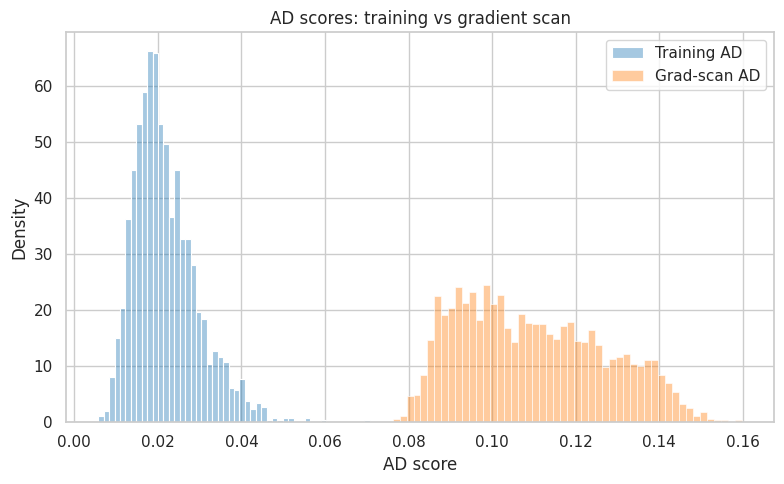

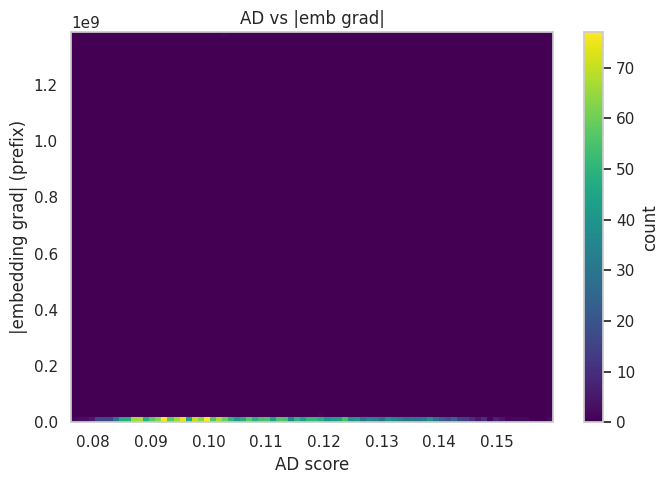

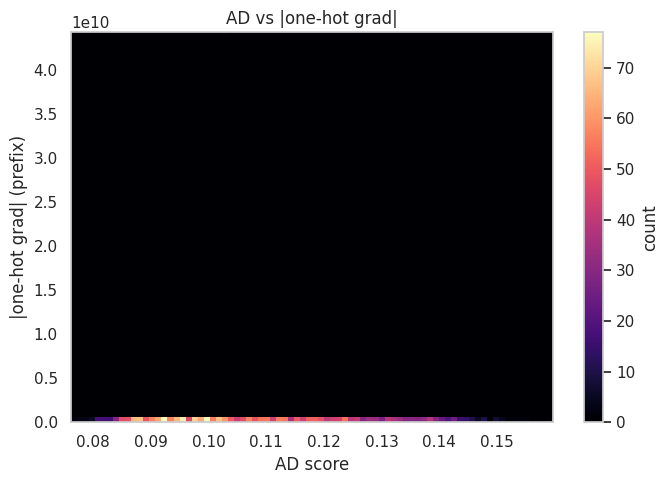

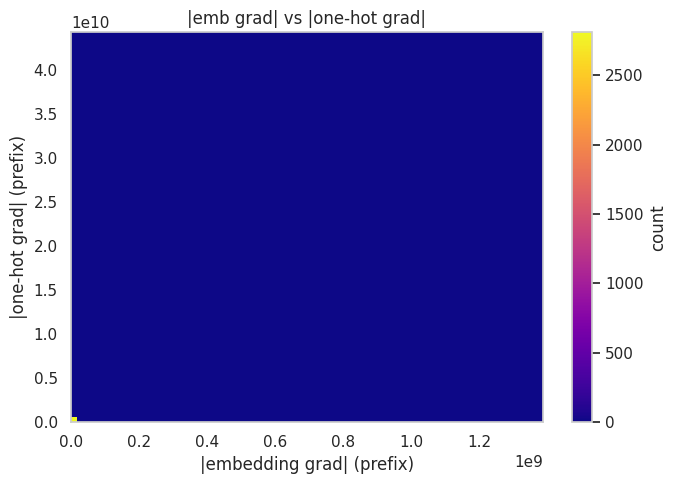

In [5]:
# ------------------------------------------------------------------
# Plots: histograms and 2D histograms
# ------------------------------------------------------------------

plt.figure(figsize=(8, 5))
if train_ad_scores.size > 0:
    sns.histplot(
        train_ad_scores,
        bins=50,
        color="tab:blue",
        stat="density",
        label="Training AD",
        alpha=0.4,
    )

sns.histplot(
    grad_scan_scores,
    bins=50,
    color="tab:orange",
    stat="density",
    label="Grad-scan AD",
    alpha=0.4,
)
plt.xlabel("AD score")
plt.ylabel("Density")
plt.title("AD scores: training vs gradient scan")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.hist2d(grad_scan_scores, emb_grad_norms, bins=80, cmap="viridis")
plt.colorbar(label="count")
plt.xlabel("AD score")
plt.ylabel("|embedding grad| (prefix)")
plt.title("AD vs |emb grad|")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.hist2d(grad_scan_scores, onehot_grad_norms, bins=80, cmap="magma")
plt.colorbar(label="count")
plt.xlabel("AD score")
plt.ylabel("|one-hot grad| (prefix)")
plt.title("AD vs |one-hot grad|")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.hist2d(emb_grad_norms, onehot_grad_norms, bins=80, cmap="plasma")
plt.colorbar(label="count")
plt.xlabel("|embedding grad| (prefix)")
plt.ylabel("|one-hot grad| (prefix)")
plt.title("|emb grad| vs |one-hot grad|")
plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------------
# Extra sanity checks / studies
# ------------------------------------------------------------------

def pearson_corr(x, y):
    if len(x) < 2 or len(y) < 2:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


mask_nonzero_emb = emb_grad_norms > 0
mask_nonzero_oh = onehot_grad_norms > 0

if mask_nonzero_emb.any():
    r_emb = pearson_corr(grad_scan_scores[mask_nonzero_emb], emb_grad_norms[mask_nonzero_emb])
    print(f"Pearson corr(AD, |emb grad|) over nonzero grads: r={r_emb:.3f}")
else:
    print("No nonzero embedding gradients to correlate.")

if mask_nonzero_oh.any():
    r_oh = pearson_corr(grad_scan_scores[mask_nonzero_oh], onehot_grad_norms[mask_nonzero_oh])
    print(f"Pearson corr(AD, |one-hot grad|) over nonzero grads: r={r_oh:.3f}")
else:
    print("No nonzero one-hot gradients to correlate.")

mask_both = mask_nonzero_emb & mask_nonzero_oh
if mask_both.any():
    r_both = pearson_corr(emb_grad_norms[mask_both], onehot_grad_norms[mask_both])
    print(f"Pearson corr(|emb grad|, |one-hot grad|): r={r_both:.3f}")

K = 10
idx_sorted = np.argsort(-grad_scan_scores)[:K]
print(f"\nTop {K} gradient-scan AD scores:")
for rank, idx in enumerate(idx_sorted, start=1):
    rec = grad_scan_records[idx]
    print(
        f"[{rank}] AD={grad_scan_scores[idx]:.6f} "
        f"|emb|={emb_grad_norms[idx]:.2e} "
        f"|onehot|={onehot_grad_norms[idx]:.2e} "
        f"type={rec.get('prefix_type')}\n"
        f"    prefix: {rec.get('prefix_text', '')[:120]}"
    )

if train_ad_scores.size > 0:
    train_idx_sorted = np.argsort(-train_ad_scores)[:K]
    print(f"\nTop {K} training AD scores:")
    for rank, idx in enumerate(train_idx_sorted, start=1):
        rec = training_records[idx]
        print(
            f"[{rank}] AD={train_ad_scores[idx]:.6f} "
            f"seq_len={rec['seq_len']}\n"
            f"    prompt: {str(rec['prompt'])[:120]}"
        )

Pearson corr(AD, |emb grad|) over nonzero grads: r=-0.008
Pearson corr(AD, |one-hot grad|) over nonzero grads: r=-0.008
Pearson corr(|emb grad|, |one-hot grad|): r=1.000

Top 10 gradient-scan AD scores:
[1] AD=0.159783 |emb|=0.00e+00 |onehot|=0.00e+00 type=random_tokens
    prefix: ĠMarried
[2] AD=0.159076 |emb|=7.43e-12 |onehot|=2.38e-10 type=random_tokens
    prefix: Ġtreasurer
[3] AD=0.155452 |emb|=1.19e-12 |onehot|=4.62e-11 type=random_words
    prefix: INES
[4] AD=0.154867 |emb|=0.00e+00 |onehot|=0.00e+00 type=random_tokens
    prefix: ĠMothers
[5] AD=0.154270 |emb|=7.34e-05 |onehot|=2.10e-03 type=random_tokens
    prefix: ĠDesigning
[6] AD=0.153813 |emb|=0.00e+00 |onehot|=0.00e+00 type=random_words
    prefix: its
[7] AD=0.152558 |emb|=0.00e+00 |onehot|=0.00e+00 type=random_tokens
    prefix: à¸²à¸¥
[8] AD=0.152489 |emb|=0.00e+00 |onehot|=0.00e+00 type=random_tokens
    prefix: è«§
[9] AD=0.151687 |emb|=0.00e+00 |onehot|=0.00e+00 type=random_tokens
    prefix: ĠBoris
[10] AD=0.15

In [7]:
# ------------------------------------------------------------------
# Top-10 prompts by each metric (AD, |emb grad|, |one-hot grad|)
# ------------------------------------------------------------------

def print_top_k(records, scores, metric_name, k=10):
    idx_sorted = np.argsort(-scores)[:k]
    print(f"\nTop {k} by {metric_name}:")
    for rank, idx in enumerate(idx_sorted, start=1):
        rec = records[idx]
        print(
            f"[{rank}] {metric_name}={scores[idx]:.6e} "
            f"type={rec.get('prefix_type', 'unknown')}\n"
            f"    prefix: {rec.get('prefix_text', '')[:200]}"
        )

print_top_k(grad_scan_records, grad_scan_scores, "AD")
print_top_k(grad_scan_records, emb_grad_norms, "|emb grad|")
print_top_k(grad_scan_records, onehot_grad_norms, "|one-hot grad|")


Top 10 by AD:
[1] AD=1.597832e-01 type=random_tokens
    prefix: ĠMarried
[2] AD=1.590757e-01 type=random_tokens
    prefix: Ġtreasurer
[3] AD=1.554518e-01 type=random_words
    prefix: INES
[4] AD=1.548670e-01 type=random_tokens
    prefix: ĠMothers
[5] AD=1.542699e-01 type=random_tokens
    prefix: ĠDesigning
[6] AD=1.538134e-01 type=random_words
    prefix: its
[7] AD=1.525583e-01 type=random_tokens
    prefix: à¸²à¸¥
[8] AD=1.524894e-01 type=random_tokens
    prefix: è«§
[9] AD=1.516867e-01 type=random_tokens
    prefix: ĠBoris
[10] AD=1.511201e-01 type=random_words
    prefix: ujo

Top 10 by |emb grad|:
[1] |emb grad|=1.387065e+09 type=random_tokens
    prefix: ĠìĤ¬ìĿ´Ð½Ð¾Ø§Ø¨ÙĩĠpolaĠtendernessĠstumbleĠpagklasĠDadçĤ¹éĴŁ_ptrjÃ¤hrFiled
[2] |emb grad|=2.406374e+07 type=random_tokens
    prefix: Ø§Ø¹Ø¨ĠDrainðĿľÕ¡ÖĢÕ£åĹĶ
[3] |emb grad|=6.061890e+05 type=random_tokens
    prefix: å¤ļå°Ķçĵ¶Ġdiscountsæĺ¾å¾ĹæľīäºĽĠÐºÑĥÐ»ÑĮÑĤÑĥÑĢĠclingingãģ¡ãĤĥéĢĢæ¬¾ĠfostĠneoĠbrakeså¿ĥç¥ŀĠemot
[4] |emb gra

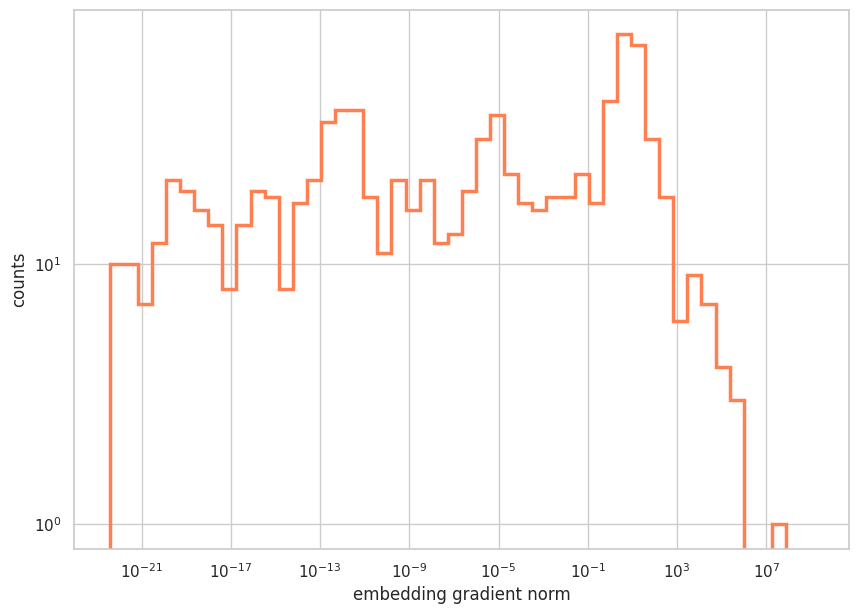

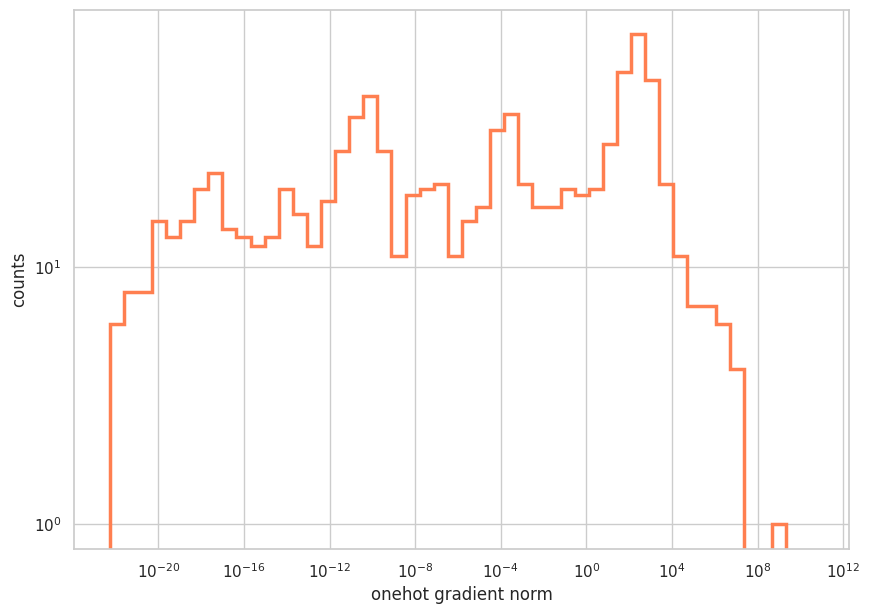

In [20]:
# Filter out zeros so log scale works; optional: use a small floor instead
emb_nonzero = emb_grad_norms[emb_grad_norms > 0]
oh_nonzero = onehot_grad_norms[onehot_grad_norms > 0]

bin_edges = np.logspace(
    np.log10(emb_nonzero.min()),
    np.log10(emb_nonzero.max()),
    51
)

plt.figure(figsize=(10,7))
plt.hist(emb_nonzero, fill=False, color='coral', linewidth=2.5, histtype='step', bins=bin_edges)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('embedding gradient norm')
plt.ylabel('counts')
plt.show()


bin_edges = np.logspace(
    np.log10(oh_nonzero.min()),
    np.log10(oh_nonzero.max()),
    51
)

plt.figure(figsize=(10,7))
plt.hist(oh_nonzero, fill=False, color='coral', linewidth=2.5, histtype='step', bins=bin_edges)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('onehot gradient norm')
plt.ylabel('counts')
plt.show()


